In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder

In [2]:
# # 加载数据
# yale = loadmat('../data/Yale_32x32.mat')
# #载入YALE32mat文件的方法，得到的x是一个字典，可以print一下他的shape看一下里面的属性

# X = yale['fea']
# X = X / 255.
# print(X.shape)
# y = yale['gnd'].T.flatten()     #将数据展开
# y= Series(y.astype(np.uint8))
# for i in range(len(X)):
#     if i % 11 == 2:
#         y[i] = 1
#     elif i % 11 == 7:
#         y[i] = 0
#     else:
#         y[i] = 2
# filter = y.isin([0, 1])
# X = X[filter]
# y = LabelEncoder().fit_transform(y[filter])

In [3]:
# 加载数据
yale = loadmat('data_aug.mat')

X = yale['data']
y = yale['labels'].T.flatten()     #将数据展开

In [4]:
from sklearn.model_selection import train_test_split
# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y)
len(X_train)

45

In [5]:
import sys
sys.path.append("..")
from lassonet import LassoNetClassifier
# 模型训练
model = LassoNetClassifier(M=30, verbose=False, path_multiplier=1.05, lambda_start=0.2)
path = model.path(X_train, y_train)

In [6]:
# # 输出特征的重要性
# img = model.feature_importances_.reshape(32, 32).T
# print(img)
# plt.title("Feature importance")
# plt.imshow(img, cmap='gray')
# plt.colorbar()
# plt.show()

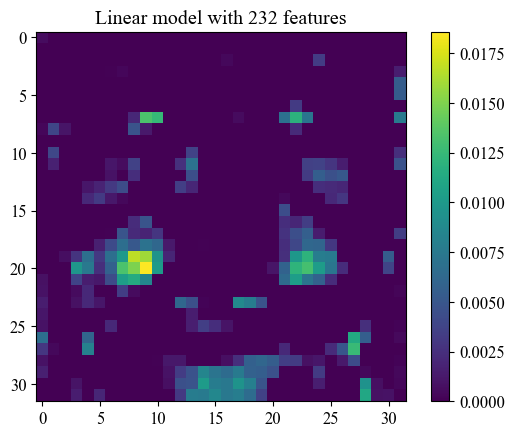

In [12]:
import torch
from matplotlib import rcParams
index = -15

weight = path[index].state_dict["skip.weight"]
importances = torch.norm(weight, p=2, dim=0) / torch.sum(torch.norm(weight, p=2, dim=0))

num = sum(path[index].selected)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(32, 32).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/yale_lassonet_selected.pdf", bbox_inches='tight')
plt.show()

Text(0, 0.5, 'number of selected features')

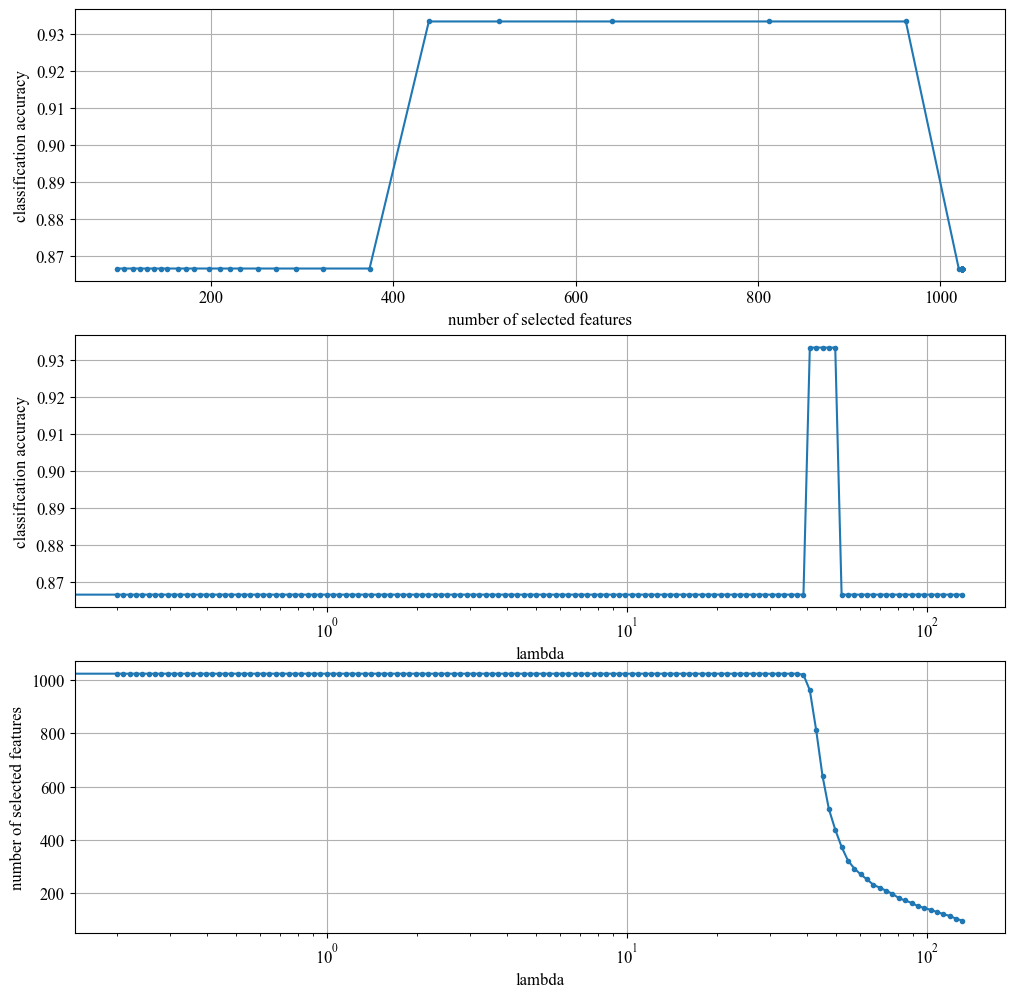

In [8]:
from sklearn.metrics import accuracy_score
n_selected = []
accuracy = []
lambda_ = []

for save in path:
    model.load(save.state_dict)
    y_pred = model.predict(X_test)
    n_selected.append(save.selected.sum())
    accuracy.append(accuracy_score(y_test, y_pred))
    lambda_.append(save.lambda_)
fig = plt.figure(figsize=(12, 12))

plt.subplot(311)
plt.grid(True)
plt.plot(n_selected, accuracy, ".-")
plt.xlabel("number of selected features")
plt.ylabel("classification accuracy")

plt.subplot(312)
plt.grid(True)
plt.plot(lambda_, accuracy, ".-")
plt.xlabel("lambda")
plt.xscale("log")
plt.ylabel("classification accuracy")

plt.subplot(313)
plt.grid(True)
plt.plot(lambda_, n_selected, ".-")
plt.xlabel("lambda")
plt.xscale("log")
plt.ylabel("number of selected features")

In [9]:
accuracy

[0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8666666666